In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/santander-customer-transaction-prediction/sample_submission.csv
/kaggle/input/santander-customer-transaction-prediction/train.csv
/kaggle/input/santander-customer-transaction-prediction/test.csv


In [2]:
train = pd.read_csv("/kaggle/input/santander-customer-transaction-prediction/train.csv")
test= pd.read_csv("/kaggle/input/santander-customer-transaction-prediction/test.csv")

In [3]:
print("Train shape:", train.shape)
print("Test shape:", test.shape)
train.head(10)

Train shape: (200000, 202)
Test shape: (200000, 201)


,ID_code,target,var_0,var_1,var_2,var_3,var_4,var_5,var_6,var_7,...,var_190,var_191,var_192,var_193,var_194,var_195,var_196,var_197,var_198,var_199
0,train_0,0,8.9255,-6.7863,11.9081,5.0930,11.4607,-9.2834,5.1187,18.6266,...,4.4354,3.9642,3.1364,1.6910,18.5227,-2.3978,7.8784,8.5635,12.7803,-1.0914
1,train_1,0,11.5006,-4.1473,13.8588,5.3890,12.3622,7.0433,5.6208,16.5338,...,7.6421,7.7214,2.5837,10.9516,15.4305,2.0339,8.1267,8.7889,18.3560,1.9518
2,train_2,0,8.6093,-2.7457,12.0805,7.8928,10.5825,-9.0837,6.9427,14.6155,...,2.9057,9.7905,1.6704,1.6858,21.6042,3.1417,-6.5213,8.2675,14.7222,0.3965
3,train_3,0,11.0604,-2.1518,8.9522,7.1957,12.5846,-1.8361,5.8428,14.9250,...,4.4666,4.7433,0.7178,1.4214,23.0347,-1.2706,-2.9275,10.2922,17.9697,-8.9996
4,train_4,0,9.8369,-1.4834,12.8746,6.6375,12.2772,2.4486,5.9405,19.2514,...,-1.4905,9.5214,-0.1508,9.1942,13.2876,-1.5121,3.9267,9.5031,17.9974,-8.8104
5,train_5,0,11.4763,-2.3182,12.6080,8.6264,10.9621,3.5609,4.5322,15.2255,...,-6.3068,6.6025,5.2912,0.4403,14.9452,1.0314,-3.6241,9.7670,12.5809,-4.7602
6,train_6,0,11.8091,-0.0832,9.3494,4.2916,11.1355,-8.0198,6.1961,12.0771,...,8.7830,6.4521,3.5325,0.1777,18.3314,0.5845,9.1104,9.1143,10.8869,-3.2097
7,train_7,0,13.5580,-7.9881,13.8776,7.5985,8.6543,0.8310,5.6890,22.3262,...,13.1700,6.5491,3.9906,5.8061,23.1407,-0.3776,4.2178,9.4237,8.6624,3.4806
8,train_8,0,16.1071,2.4426,13.9307,5.6327,8.8014,6.1630,4.4514,10.1854,...,1.4298,14.7510,1.6395,1.4181,14.8370,-1.9940,-1.0733,8.1975,19.5114,4.8453
9,train_9,0,12.5088,1.9743,8.8960,5.4508,13.6043,-16.2859,6.0637,16.8410,...,0.5543,6.3160,1.0371,3.6885,14.8344,0.4467,14.1287,7.9133,16.2375,14.2514


In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

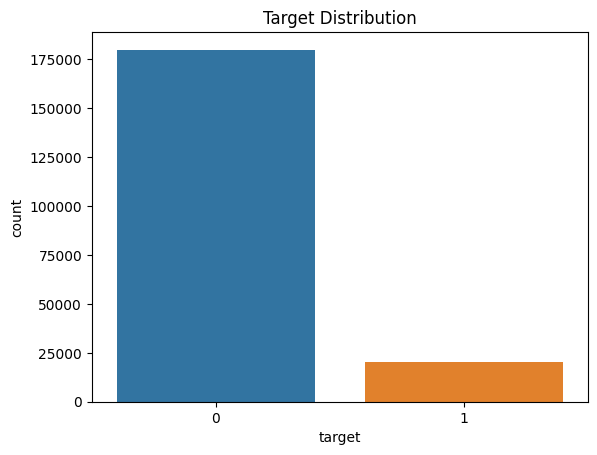

target
0    0.89951
1    0.10049
Name: proportion, dtype: float64


In [5]:
sns.countplot(x="target", data=train)
plt.title("Target Distribution")
plt.show()
print(train["target"].value_counts(normalize=True))

In [6]:
train.describe().T

,count,mean,std,min,25%,50%,75%,max
target,200000.0,0.100490,0.300653,0.0000,0.000000,0.00000,0.000000,1.0000
var_0,200000.0,10.679914,3.040051,0.4084,8.453850,10.52475,12.758200,20.3150
var_1,200000.0,-1.627622,4.050044,-15.0434,-4.740025,-1.60805,1.358625,10.3768
var_2,200000.0,10.715192,2.640894,2.1171,8.722475,10.58000,12.516700,19.3530
var_3,200000.0,6.796529,2.043319,-0.0402,5.254075,6.82500,8.324100,13.1883
...,...,...,...,...,...,...,...,...
var_195,200000.0,-0.142088,1.429372,-5.2610,-1.170700,-0.17270,0.829600,4.2729
var_196,200000.0,2.303335,5.454369,-14.2096,-1.946925,2.40890,6.556725,18.3215
var_197,200000.0,8.908158,0.921625,5.9606,8.252800,8.88820,9.593300,12.0004
var_198,200000.0,15.870720,3.010945,6.2993,13.829700,15.93405,18.064725,26.0791


/usr/local/lib/python3.11/dist-packages/matplotlib/colors.py:721: RuntimeWarning: invalid value encountered in less
  xa[xa < 0] = -1


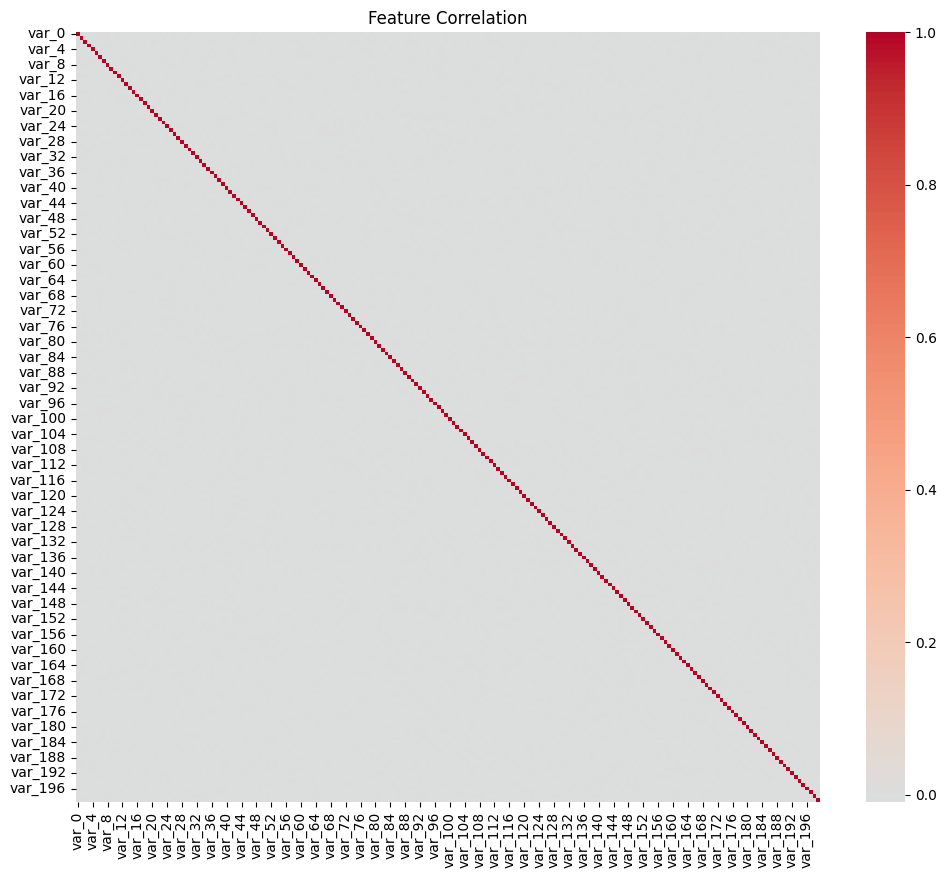

In [7]:
# Feature columns
features = [col for col in train.columns if col.startswith("var_")]
# Correlation heatmap (subset)
corr = train[features].corr()
plt.figure(figsize=(12, 10))
sns.heatmap(corr, cmap="coolwarm", center=0)
plt.title("Feature Correlation")
plt.show()

In [13]:
# Drop ID column
train.drop(columns=["ID_code"], inplace=True)
test.drop(columns=["ID_code"], inplace=True)

# Drop or fill missing values
print("Missing values in train:", train.isnull().sum().sum())
train.dropna(inplace=True)  # or train.fillna(train.mean())

# Feature columns (ensure numeric only)
features = train.select_dtypes(include=[np.number]).columns.tolist()
features.remove("target")

# -----------------------------------------------
# 1. Drop highly correlated features (Pearson > 0.8)
# -----------------------------------------------
corr_matrix = train[features].corr().abs()
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
to_drop = [column for column in upper.columns if any(upper[column] > 0.8)]

print(f"Dropping {len(to_drop)} highly correlated features.")
train.drop(columns=to_drop, inplace=True)
test.drop(columns=to_drop, inplace=True, errors='ignore')  # in case test lacks some columns

# -----------------------------------------------
# 2. Handle Outliers (clip using IQR method)
# -----------------------------------------------
def clip_outliers(df, feature_cols):
    for col in feature_cols:
        if pd.api.types.is_numeric_dtype(df[col]):
            Q1 = df[col].quantile(0.25)
            Q3 = df[col].quantile(0.75)
            IQR = Q3 - Q1
            lower = Q1 - 1.5 * IQR
            upper = Q3 + 1.5 * IQR
            df[col] = df[col].clip(lower=lower, upper=upper)
    return df

numeric_features = [col for col in train.columns if col != "target" and pd.api.types.is_numeric_dtype(train[col])]

train = clip_outliers(train, numeric_features)
test = clip_outliers(test, [col for col in test.columns if pd.api.types.is_numeric_dtype(test[col])])

# Final check
print("Final train shape:", train.shape)
print("Final test shape:", test.shape)

Missing values in train: 0


/usr/local/lib/python3.11/dist-packages/pandas/core/computation/expressions.py:73: RuntimeWarning: invalid value encountered in greater
  return op(a, b)


Dropping 0 highly correlated features.
Final train shape: (200000, 201)
Final test shape: (200000, 200)


In [14]:
from sklearn.decomposition import PCA
from sklearn.feature_selection import mutual_info_classif
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np


In [15]:
X = train.drop(columns=["target"])
y = train["target"]


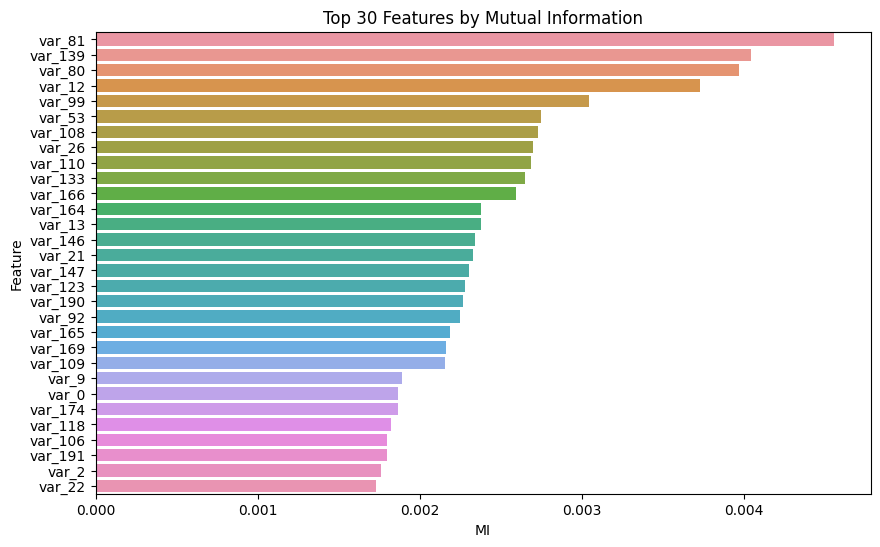

In [16]:
# Mutual Information between features and target
mi_scores = mutual_info_classif(X, y, discrete_features=False, random_state=42)

# Convert to DataFrame
mi_df = pd.DataFrame({"Feature": X.columns, "MI": mi_scores})
mi_df.sort_values("MI", ascending=False, inplace=True)

# Select top N features (say 30)
top_mi_features = mi_df.head(30)["Feature"].tolist()

# Plot
plt.figure(figsize=(10, 6))
sns.barplot(x="MI", y="Feature", data=mi_df.head(30))
plt.title("Top 30 Features by Mutual Information")
plt.show()


In [17]:
X_new = train[top_mi_features]
y = train["target"]

# Standardize features (for LR)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_new)

# Split dataset
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, stratify=y, random_state=42)

# ----------------------------
# 2. Model Setup
# ----------------------------
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Decision Tree": DecisionTreeClassifier(max_depth=10, random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42)
}


In [39]:
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    roc_curve, auc
)
import matplotlib.pyplot as plt

def evaluate_models(models, X_train, y_train, X_test, y_test):
    for name, model in models.items():
        print(f"\n🔹 Training: {name}")
        
        # Fit the model
        model.fit(X_train, y_train)
        
        # Predict labels
        y_pred = model.predict(X_test)
        
        # Try to get predicted probabilities (for ROC curve)
        try:
            y_proba = model.predict_proba(X_test)[:, 1]
        except AttributeError:
            # Some models (like SVM with no probability=True) don't support predict_proba
            y_proba = None
        
        # Print metrics
        print("Accuracy :", accuracy_score(y_test, y_pred))
        print("Precision:", precision_score(y_test, y_pred))
        print("Recall   :", recall_score(y_test, y_pred))
        print("F1-Score :", f1_score(y_test, y_pred))
        
        print("\nClassification Report:")
        print(classification_report(y_test, y_pred, digits=4))
        
        # Confusion matrix
        cm = confusion_matrix(y_test, y_pred)
        disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[0, 1])
        disp.plot(cmap='Blues')
        plt.title(f"Confusion Matrix - {name}")
        plt.show()
        
        # ROC curve
        if y_proba is not None:
            fpr, tpr, thresholds = roc_curve(y_test, y_proba)
            roc_auc = auc(fpr, tpr)

            plt.figure(figsize=(8, 6))
            plt.plot(fpr, tpr, label=f"ROC Curve (AUC = {roc_auc:.4f})")
            plt.plot([0, 1], [0, 1], 'k--')
            plt.xlabel("False Positive Rate")
            plt.ylabel("True Positive Rate")
            plt.title(f"ROC Curve - {name}")
            plt.legend(loc="lower right")
            plt.grid(True)
            plt.show()
        else:
            print("⚠️ ROC Curve skipped: Model does not support `predict_proba`.")



🔹 Training: Logistic Regression
Accuracy : 0.901625
Precision: 0.6430976430976431
Recall   : 0.047512437810945274
F1-Score : 0.08848737549223998

Classification Report:
              precision    recall  f1-score   support

           0     0.9036    0.9971    0.9480     35980
           1     0.6431    0.0475    0.0885      4020

    accuracy                         0.9016     40000
   macro avg     0.7733    0.5223    0.5182     40000
weighted avg     0.8774    0.9016    0.8616     40000



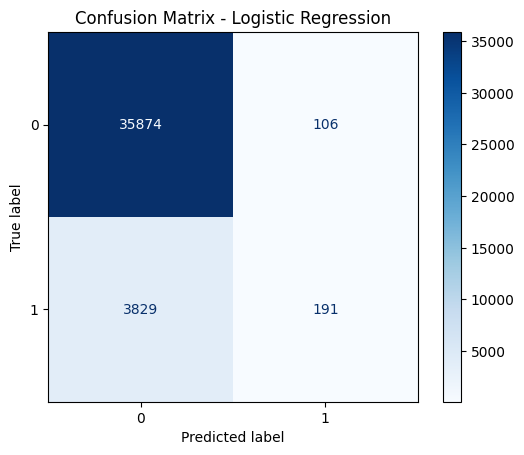

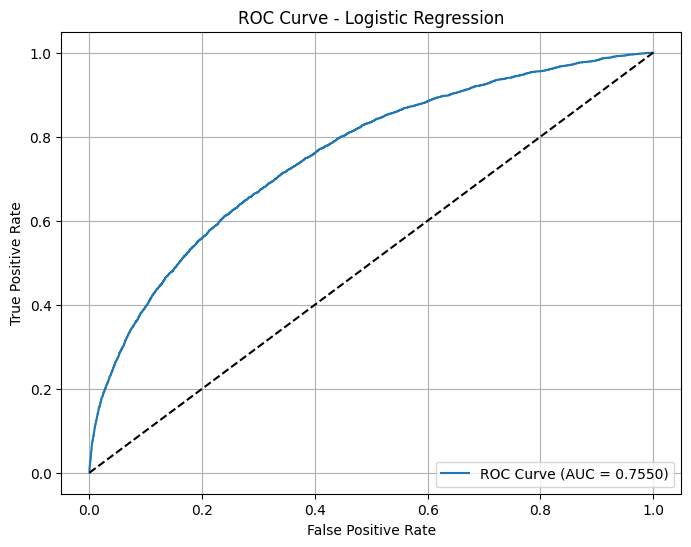


🔹 Training: Decision Tree
Accuracy : 0.896225
Precision: 0.3761814744801512
Recall   : 0.04950248756218906
F1-Score : 0.08749175642998462

Classification Report:
              precision    recall  f1-score   support

           0     0.9032    0.9908    0.9450     35980
           1     0.3762    0.0495    0.0875      4020

    accuracy                         0.8962     40000
   macro avg     0.6397    0.5202    0.5162     40000
weighted avg     0.8502    0.8962    0.8588     40000



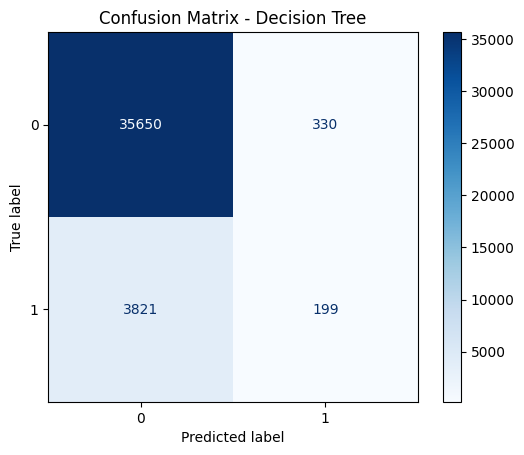

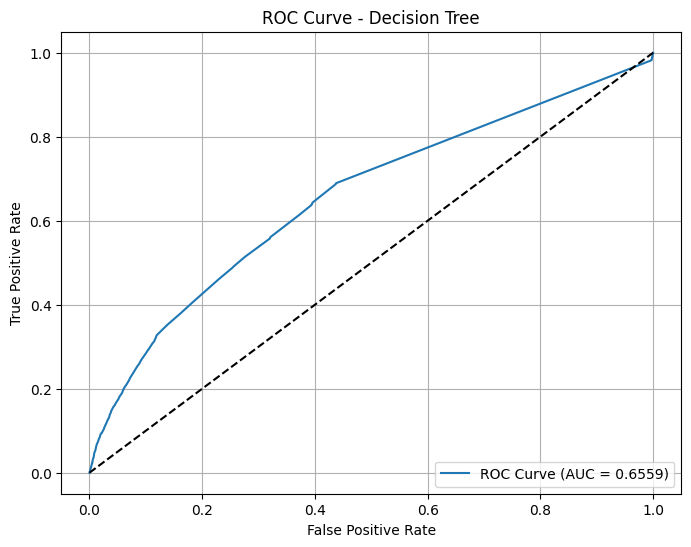


🔹 Training: Random Forest
Accuracy : 0.900575
Precision: 0.8028169014084507
Recall   : 0.014179104477611941
F1-Score : 0.02786604742116842

Classification Report:
              precision    recall  f1-score   support

           0     0.9007    0.9996    0.9476     35980
           1     0.8028    0.0142    0.0279      4020

    accuracy                         0.9006     40000
   macro avg     0.8518    0.5069    0.4877     40000
weighted avg     0.8909    0.9006    0.8552     40000



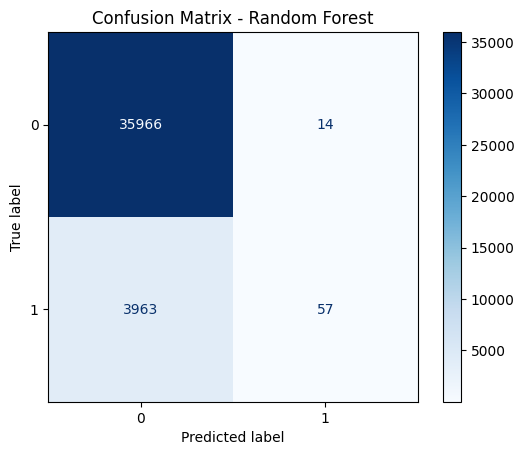

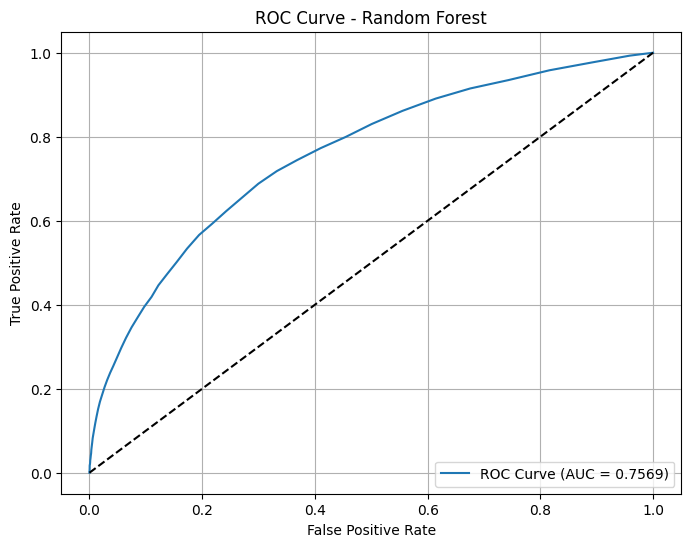

In [40]:
evaluate_models(models, X_train, y_train, X_test, y_test)

In [43]:
test

,var_0,var_1,var_2,var_3,var_4,var_5,var_6,var_7,var_8,var_9,...,var_190,var_191,var_192,var_193,var_194,var_195,var_196,var_197,var_198,var_199
0,11.0656,7.7798,12.9536,9.4292,11.4327,-2.3805,5.8493,18.2675,2.1337,8.8100,...,-2.1556,11.8495,-1.4300,2.4508,13.7112,2.4669,4.3654,10.7200,15.4722,-8.7197
1,8.5304,1.2543,11.3047,5.1858,9.1974,-4.0117,6.0196,18.6316,-4.4131,5.9739,...,10.6165,8.8349,0.9403,10.1282,15.5765,0.4773,-1.4852,9.8714,19.1293,-20.9760
2,5.4827,-10.3581,10.1407,7.0479,10.2628,9.8052,4.8950,20.2537,1.5233,8.3442,...,-0.7484,10.9935,1.9803,2.1800,12.9813,2.1281,-7.1086,7.0618,19.8956,-23.1794
3,8.5374,-1.3222,12.0220,6.5749,8.8458,3.1744,4.9397,20.5660,3.3755,7.4578,...,9.5702,9.0766,1.6580,3.5813,15.1874,3.1656,3.9567,9.2295,13.0168,-4.2108
4,11.7058,-0.1327,14.1295,7.7506,9.1035,-8.5848,6.8595,10.6048,2.9890,7.1437,...,4.2259,9.1723,1.2835,3.3778,19.5542,-0.2860,-5.1612,7.2882,13.9260,-9.1846
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
199995,13.1678,1.0136,10.4333,6.7997,8.5974,-4.1641,4.8579,14.7625,-2.7239,6.9937,...,2.0544,9.6849,4.6734,-1.3660,12.8721,1.2013,-4.6195,9.1568,18.2102,4.8801
199996,9.7171,-9.1462,7.3443,9.1421,12.8936,3.0191,5.6888,18.8862,5.0915,6.3545,...,5.0071,6.6548,1.8197,2.4104,18.9037,-0.9337,2.9995,9.1112,18.1740,-20.7689
199997,11.6360,2.2769,11.2074,7.7649,12.6796,11.3224,5.3883,18.3794,1.6603,5.7341,...,5.1536,2.6498,2.4937,-0.0637,20.0609,-1.1742,-4.1524,9.1933,11.7905,-22.2762
199998,13.5745,-0.5134,13.6584,7.4855,11.2241,-11.3037,4.1959,16.8280,5.3208,8.9032,...,3.4259,8.5012,2.2713,5.7621,17.0056,1.1763,-2.3761,8.1079,8.7735,-0.2122


In [61]:
test_ids = [f"test_{i}" for i in range(0,200000)]

# Ensure test data uses same selected features
X_test_final = test[top_mi_features]

# Scale test data using the same scaler
X_test_final_scaled = scaler.transform(X_test_final)

# Predict probabilities or class labels
test_preds = models["Logistic Regression"].predict(X_test_final_scaled)  # probability of class 1

# Create submission DataFrame
submission = pd.DataFrame({
    "ID_code": test_ids,
    
    "target": test_preds
})

# Save to CSV
submission.to_csv("submission.csv", index=False)
print("✅ Submission file 'submission.csv' created.")

✅ Submission file 'submission.csv' created.


In [62]:
submission

,ID_code,target
0,test_0,0
1,test_1,0
2,test_2,0
3,test_3,0
4,test_4,0
...,...,...
199995,test_199995,0
199996,test_199996,0
199997,test_199997,0
199998,test_199998,0


In [63]:
import numpy as np

unique, counts = np.unique(test_preds, return_counts=True)
count_dict = dict(zip(unique, counts))

print("🔢 Prediction Counts in Test Set:")
for label in [0, 1]:
    print(f"Class {label}: {count_dict.get(label, 0)}")


🔢 Prediction Counts in Test Set:
Class 0: 198651
Class 1: 1349
